# Student Performance Prediction

## Project Overview
This notebook implements a machine learning pipeline to predict student GPA based on various demographic and socioeconomic features. The analysis includes data exploration, preprocessing, feature engineering, model training, and comparison of multiple regression techniques.

## Contents
1. **Data Loading & Exploration** - Load and inspect training, test, and validation datasets
2. **Data Preprocessing** - Encode categorical variables and handle data types
3. **Exploratory Data Analysis** - Visualize distributions and relationships
4. **Model Development** - Train multiple regression models
5. **Model Evaluation** - Compare performance and select the best model
6. **Hyperparameter Tuning** - Optimize model parameters using grid and random search
7. **Final Diagnostics** - Validate predictions and save the model

## 1. Setup & Libraries

Import all necessary libraries for data analysis, visualization, and machine learning.

In [1]:
# Importing necessary Libraries
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Data Loading & Exploration

### 2.1 Training Data

Load and examine the training dataset to understand its structure and characteristics.

In [ ]:
df_train = pd.read_csv('datasets/train.csv')

In [3]:
df_train.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,17,12,Female,White,3,HS,Public,Suburban,70.258235,79.665185,...,2.743879,0.906809,1.089243,1,1,0,0,0,2,2
1,18,12,Female,White,2,HS,Public,Suburban,67.876546,59.611505,...,2.587700,0.843739,0.879911,1,1,0,1,0,5,2
2,16,11,Female,White,2,HS,Public,City,62.070623,70.577443,...,2.426294,0.850923,1.003442,1,1,0,1,1,5,1
3,14,9,Female,White,4,Bachelors+,Public,Town,79.909312,82.924450,...,3.558240,0.946786,1.814810,1,1,0,1,0,4,2
4,16,11,Female,Two-or-more,4,SomeCollege,Public,Rural,90.562294,95.352336,...,3.896884,0.988036,1.157241,1,1,0,0,0,3,4


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000774 entries, 0 to 8000773
Data columns (total 21 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Age                int64  
 1   Grade              int64  
 2   Gender             object 
 3   Race               object 
 4   SES_Quartile       int64  
 5   ParentalEducation  object 
 6   SchoolType         object 
 7   Locale             object 
 8   TestScore_Math     float64
 9   TestScore_Reading  float64
 10  TestScore_Science  float64
 11  GPA                float64
 12  AttendanceRate     float64
 13  StudyHours         float64
 14  InternetAccess     int64  
 15  Extracurricular    int64  
 16  PartTimeJob        int64  
 17  ParentSupport      int64  
 18  Romantic           int64  
 19  FreeTime           int64  
 20  GoOut              int64  
dtypes: float64(6), int64(10), object(5)
memory usage: 1.3+ GB


In [5]:
df_train.describe()

,Age,Grade,SES_Quartile,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
count,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06,8.000774e+06
mean,1.599959e+01,1.079974e+01,2.499802e+00,7.497554e+01,7.497894e+01,7.497851e+01,2.996743e+00,8.995891e-01,9.997262e-01,8.498267e-01,5.499690e-01,1.798985e-01,4.233363e-01,1.998450e-01,3.000327e+00,2.072786e+00
std,1.413915e+00,1.165974e+00,1.118161e+00,9.944944e+00,9.943306e+00,9.948554e+00,4.595127e-01,4.806154e-02,3.481091e-01,3.572413e-01,4.974969e-01,3.841029e-01,4.940878e-01,3.998838e-01,1.008895e+00,9.184358e-01
min,1.400000e+01,9.000000e+00,1.000000e+00,2.257681e+01,2.118797e+01,1.918883e+01,7.131814e-01,7.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
25%,1.500000e+01,1.000000e+01,1.000000e+00,6.824699e+01,6.825267e+01,6.825523e+01,2.685036e+00,8.669519e-01,7.642085e-01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,1.000000e+00
50%,1.600000e+01,1.100000e+01,3.000000e+00,7.499531e+01,7.500211e+01,7.500176e+01,2.999824e+00,8.999776e-01,9.998944e-01,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+00,2.000000e+00
75%,1.700000e+01,1.200000e+01,3.000000e+00,8.174198e+01,8.174334e+01,8.174174e+01,3.314440e+00,9.330400e-01,1.235127e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,4.000000e+00,3.000000e+00
max,1.800000e+01,1.200000e+01,4.000000e+00,1.000000e+02,1.000000e+02,1.000000e+02,4.000000e+00,1.000000e+00,2.793829e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,5.000000e+00,5.000000e+00


### 2.2 Data Preprocessing - Training Data

**Encoding Categorical Variables**

Convert categorical features (Gender, Race, Parental Education, School Type, Locale) into numerical format suitable for machine learning models:
- **Gender**: Female → 0, Male → 1
- **Race, Parental Education, Locale**: Label encoded
- **School Type**: Public → 0, Private → 1

In [6]:
# COnverting Categorical Data Columns into Encoded Format

df_train["Gender"] = df_train["Gender"].map({
    "Female" : 0,
    "Male" : 1
})

df_train["Gender"] = df_train["Gender"].astype(int)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_train["Race"] = le.fit_transform(df_train["Race"])

df_train["Race"] = df_train["Race"].astype(int)

df_train["ParentalEducation"] = le.fit_transform(df_train["ParentalEducation"])

df_train["ParentalEducation"] = df_train["ParentalEducation"].astype(int)

df_train["SchoolType"] = df_train["SchoolType"].map({
    "Public" : 0,
    "Private" : 1
})

df_train["SchoolType"] = df_train["SchoolType"].astype(int)

df_train["Locale"] = le.fit_transform(df_train["Locale"])

df_train["Locale"] = df_train["Locale"].astype(int)

In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000774 entries, 0 to 8000773
Data columns (total 21 columns):
 #   Column             Dtype  
---  ------             -----  
 0   Age                int64  
 1   Grade              int64  
 2   Gender             int64  
 3   Race               int64  
 4   SES_Quartile       int64  
 5   ParentalEducation  int64  
 6   SchoolType         int64  
 7   Locale             int64  
 8   TestScore_Math     float64
 9   TestScore_Reading  float64
 10  TestScore_Science  float64
 11  GPA                float64
 12  AttendanceRate     float64
 13  StudyHours         float64
 14  InternetAccess     int64  
 15  Extracurricular    int64  
 16  PartTimeJob        int64  
 17  ParentSupport      int64  
 18  Romantic           int64  
 19  FreeTime           int64  
 20  GoOut              int64  
dtypes: float64(6), int64(15)
memory usage: 1.3 GB


In [8]:
df_train.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,17,12,0,5,3,2,0,2,70.258235,79.665185,...,2.743879,0.906809,1.089243,1,1,0,0,0,2,2
1,18,12,0,5,2,2,0,2,67.876546,59.611505,...,2.587700,0.843739,0.879911,1,1,0,1,0,5,2
2,16,11,0,5,2,2,0,0,62.070623,70.577443,...,2.426294,0.850923,1.003442,1,1,0,1,1,5,1
3,14,9,0,5,4,1,0,3,79.909312,82.924450,...,3.558240,0.946786,1.814810,1,1,0,1,0,4,2
4,16,11,0,4,4,3,0,1,90.562294,95.352336,...,3.896884,0.988036,1.157241,1,1,0,0,0,3,4


### 2.3 Test Data

Load and examine the test dataset, which will be used to evaluate the final model performance.

In [9]:
df_test = pd.read_csv('datasets/test.csv')

In [10]:
df_test.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,15,10,Female,White,1,HS,Public,City,72.346053,62.217134,...,2.521745,0.868836,0.310172,0,1,1,1,0,3,3
1,16,11,Female,Hispanic,1,<HS,Private,City,77.889157,72.748030,...,3.275626,0.909595,1.175586,1,1,0,0,1,3,1
2,17,12,Female,Black,2,HS,Public,Rural,72.966587,65.585472,...,2.974137,0.870952,1.112556,1,1,0,0,0,3,3
3,16,11,Female,White,2,HS,Public,Town,96.674049,88.035852,...,3.676590,1.000000,1.067679,0,0,0,0,1,4,5
4,16,11,Male,Black,3,Bachelors+,Public,Rural,81.989270,77.485372,...,2.255014,0.897957,0.841936,0,1,0,1,0,4,2


In [11]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999997 entries, 0 to 999996
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                999997 non-null  int64  
 1   Grade              999997 non-null  int64  
 2   Gender             999997 non-null  object 
 3   Race               999997 non-null  object 
 4   SES_Quartile       999997 non-null  int64  
 5   ParentalEducation  999997 non-null  object 
 6   SchoolType         999997 non-null  object 
 7   Locale             999997 non-null  object 
 8   TestScore_Math     999997 non-null  float64
 9   TestScore_Reading  999997 non-null  float64
 10  TestScore_Science  999997 non-null  float64
 11  GPA                999997 non-null  float64
 12  AttendanceRate     999997 non-null  float64
 13  StudyHours         999997 non-null  float64
 14  InternetAccess     999997 non-null  int64  
 15  Extracurricular    999997 non-null  int64  
 16  Pa

In [12]:
df_test.describe()

,Age,Grade,SES_Quartile,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
count,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000,999997.000000
mean,15.999193,10.799551,2.500284,74.980073,74.978168,74.983955,2.996760,0.899562,0.999933,0.850403,0.549809,0.180610,0.422772,0.200068,3.002909,2.072477
std,1.413712,1.165967,1.117889,9.944334,9.954602,9.946251,0.459472,0.048024,0.348642,0.356677,0.497513,0.384695,0.494000,0.400051,1.008419,0.919165
min,14.000000,9.000000,1.000000,29.146751,30.796723,26.915868,0.752867,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,15.000000,10.000000,2.000000,68.248703,68.250126,68.264300,2.684924,0.866991,0.763883,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000
50%,16.000000,11.000000,3.000000,74.998702,74.985049,74.997447,2.999782,0.899881,0.999841,1.000000,1.000000,0.000000,0.000000,0.000000,3.000000,2.000000
75%,17.000000,12.000000,3.000000,81.750240,81.746642,81.739127,3.314308,0.932912,1.236215,1.000000,1.000000,0.000000,1.000000,0.000000,4.000000,3.000000
max,18.000000,12.000000,4.000000,100.000000,100.000000,100.000000,4.000000,1.000000,2.590730,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000


### 2.4 Data Preprocessing - Test Data

**Encoding Categorical Variables**

Apply the same encoding transformations to the test dataset as were applied to the training data.

In [13]:
# COnverting Categorical Data Columns into Encoded Format

df_test["Gender"] = df_test["Gender"].map({
    "Female" : 0,
    "Male" : 1
})

df_test["Gender"] = df_test["Gender"].astype(int)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_test["Race"] = le.fit_transform(df_test["Race"])

df_test["Race"] = df_test["Race"].astype(int)

df_test["ParentalEducation"] = le.fit_transform(df_test["ParentalEducation"])

df_test["ParentalEducation"] = df_test["ParentalEducation"].astype(int)

df_test["SchoolType"] = df_test["SchoolType"].map({
    "Public" : 0,
    "Private" : 1
})

df_test["SchoolType"] = df_test["SchoolType"].astype(int)

df_test["Locale"] = le.fit_transform(df_test["Locale"])

df_test["Locale"] = df_test["Locale"].astype(int)

In [14]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999997 entries, 0 to 999996
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                999997 non-null  int64  
 1   Grade              999997 non-null  int64  
 2   Gender             999997 non-null  int64  
 3   Race               999997 non-null  int64  
 4   SES_Quartile       999997 non-null  int64  
 5   ParentalEducation  999997 non-null  int64  
 6   SchoolType         999997 non-null  int64  
 7   Locale             999997 non-null  int64  
 8   TestScore_Math     999997 non-null  float64
 9   TestScore_Reading  999997 non-null  float64
 10  TestScore_Science  999997 non-null  float64
 11  GPA                999997 non-null  float64
 12  AttendanceRate     999997 non-null  float64
 13  StudyHours         999997 non-null  float64
 14  InternetAccess     999997 non-null  int64  
 15  Extracurricular    999997 non-null  int64  
 16  Pa

In [15]:
df_test.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,15,10,0,5,1,2,0,0,72.346053,62.217134,...,2.521745,0.868836,0.310172,0,1,1,1,0,3,3
1,16,11,0,2,1,0,1,0,77.889157,72.748030,...,3.275626,0.909595,1.175586,1,1,0,0,1,3,1
2,17,12,0,1,2,2,0,1,72.966587,65.585472,...,2.974137,0.870952,1.112556,1,1,0,0,0,3,3
3,16,11,0,5,2,2,0,3,96.674049,88.035852,...,3.676590,1.000000,1.067679,0,0,0,0,1,4,5
4,16,11,1,1,3,1,0,1,81.989270,77.485372,...,2.255014,0.897957,0.841936,0,1,0,1,0,4,2


### 2.5 Validation Data

Load and examine the validation dataset, which will be used to compare different models during training.

In [16]:
df_val = pd.read_csv('datasets/validation.csv')

In [17]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999229 entries, 0 to 999228
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                999229 non-null  int64  
 1   Grade              999229 non-null  int64  
 2   Gender             999229 non-null  object 
 3   Race               999229 non-null  object 
 4   SES_Quartile       999229 non-null  int64  
 5   ParentalEducation  999229 non-null  object 
 6   SchoolType         999229 non-null  object 
 7   Locale             999229 non-null  object 
 8   TestScore_Math     999229 non-null  float64
 9   TestScore_Reading  999229 non-null  float64
 10  TestScore_Science  999229 non-null  float64
 11  GPA                999229 non-null  float64
 12  AttendanceRate     999229 non-null  float64
 13  StudyHours         999229 non-null  float64
 14  InternetAccess     999229 non-null  int64  
 15  Extracurricular    999229 non-null  int64  
 16  Pa

In [18]:
df_val.describe()

,Age,Grade,SES_Quartile,TestScore_Math,TestScore_Reading,TestScore_Science,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
count,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000,999229.000000
mean,16.000606,10.800790,2.499297,74.969348,74.986900,74.980436,2.996990,0.899570,1.000338,0.849713,0.550239,0.179856,0.422903,0.199798,2.998400,2.071461
std,1.413524,1.165726,1.118043,9.953549,9.942880,9.952319,0.459929,0.048066,0.348139,0.357353,0.497470,0.384067,0.494021,0.399849,1.008821,0.917266
min,14.000000,9.000000,1.000000,24.956829,26.877302,27.577756,0.859093,0.700000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,15.000000,10.000000,1.000000,68.231973,68.258701,68.254205,2.685326,0.866895,0.764862,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000
50%,16.000000,11.000000,2.000000,75.001566,75.003040,74.997514,3.000378,0.899966,1.000138,1.000000,1.000000,0.000000,0.000000,0.000000,3.000000,2.000000
75%,17.000000,12.000000,3.000000,81.740958,81.745880,81.752702,3.314793,0.933054,1.235797,1.000000,1.000000,0.000000,1.000000,0.000000,4.000000,3.000000
max,18.000000,12.000000,4.000000,100.000000,100.000000,100.000000,4.000000,1.000000,2.801384,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000


### 2.6 Data Preprocessing - Validation Data

**Encoding Categorical Variables**

Apply the same encoding transformations to the validation dataset as were applied to the training data.

In [19]:
# COnverting Categorical Data Columns into Encoded Format

df_val["Gender"] = df_val["Gender"].map({
    "Female" : 0,
    "Male" : 1
})

df_val["Gender"] = df_val["Gender"].astype(int)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_val["Race"] = le.fit_transform(df_val["Race"])

df_val["Race"] = df_val["Race"].astype(int)

df_val["ParentalEducation"] = le.fit_transform(df_val["ParentalEducation"])

df_val["ParentalEducation"] = df_val["ParentalEducation"].astype(int)

df_val["SchoolType"] = df_val["SchoolType"].map({
    "Public" : 0,
    "Private" : 1
})

df_val["SchoolType"] = df_val["SchoolType"].astype(int)

df_val["Locale"] = le.fit_transform(df_val["Locale"])

df_val["Locale"] = df_val["Locale"].astype(int)

In [20]:
df_val.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999229 entries, 0 to 999228
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                999229 non-null  int64  
 1   Grade              999229 non-null  int64  
 2   Gender             999229 non-null  int64  
 3   Race               999229 non-null  int64  
 4   SES_Quartile       999229 non-null  int64  
 5   ParentalEducation  999229 non-null  int64  
 6   SchoolType         999229 non-null  int64  
 7   Locale             999229 non-null  int64  
 8   TestScore_Math     999229 non-null  float64
 9   TestScore_Reading  999229 non-null  float64
 10  TestScore_Science  999229 non-null  float64
 11  GPA                999229 non-null  float64
 12  AttendanceRate     999229 non-null  float64
 13  StudyHours         999229 non-null  float64
 14  InternetAccess     999229 non-null  int64  
 15  Extracurricular    999229 non-null  int64  
 16  Pa

In [21]:
df_val.head()

,Age,Grade,Gender,Race,SES_Quartile,ParentalEducation,SchoolType,Locale,TestScore_Math,TestScore_Reading,...,GPA,AttendanceRate,StudyHours,InternetAccess,Extracurricular,PartTimeJob,ParentSupport,Romantic,FreeTime,GoOut
0,14,9,0,2,3,3,0,0,90.186244,88.390291,...,3.509322,0.964022,1.409700,1,1,0,0,0,1,4
1,17,12,0,5,4,3,0,1,73.356297,73.471428,...,3.118458,0.882988,1.112296,1,0,0,1,0,3,3
2,17,12,0,3,2,2,0,2,73.970459,76.085029,...,3.640436,0.864401,1.214927,1,1,1,1,1,1,1
3,15,10,1,5,4,3,0,2,64.500290,63.858629,...,2.990611,0.887791,0.155258,1,0,0,1,0,5,4
4,18,12,1,1,3,2,0,0,84.546267,88.502675,...,3.546262,0.933201,0.908776,1,1,0,0,1,3,3


In [22]:
df_train.isnull().sum()

Age                  0
Grade                0
Gender               0
Race                 0
SES_Quartile         0
ParentalEducation    0
SchoolType           0
Locale               0
TestScore_Math       0
TestScore_Reading    0
TestScore_Science    0
GPA                  0
AttendanceRate       0
StudyHours           0
InternetAccess       0
Extracurricular      0
PartTimeJob          0
ParentSupport        0
Romantic             0
FreeTime             0
GoOut                0
dtype: int64

In [23]:
df_test.isnull().sum()

Age                  0
Grade                0
Gender               0
Race                 0
SES_Quartile         0
ParentalEducation    0
SchoolType           0
Locale               0
TestScore_Math       0
TestScore_Reading    0
TestScore_Science    0
GPA                  0
AttendanceRate       0
StudyHours           0
InternetAccess       0
Extracurricular      0
PartTimeJob          0
ParentSupport        0
Romantic             0
FreeTime             0
GoOut                0
dtype: int64

In [24]:
df_val.isnull().sum()

Age                  0
Grade                0
Gender               0
Race                 0
SES_Quartile         0
ParentalEducation    0
SchoolType           0
Locale               0
TestScore_Math       0
TestScore_Reading    0
TestScore_Science    0
GPA                  0
AttendanceRate       0
StudyHours           0
InternetAccess       0
Extracurricular      0
PartTimeJob          0
ParentSupport        0
Romantic             0
FreeTime             0
GoOut                0
dtype: int64

## 3. Exploratory Data Analysis (EDA)

Perform comprehensive exploratory data analysis to understand feature distributions, relationships, and identify patterns in student performance data.

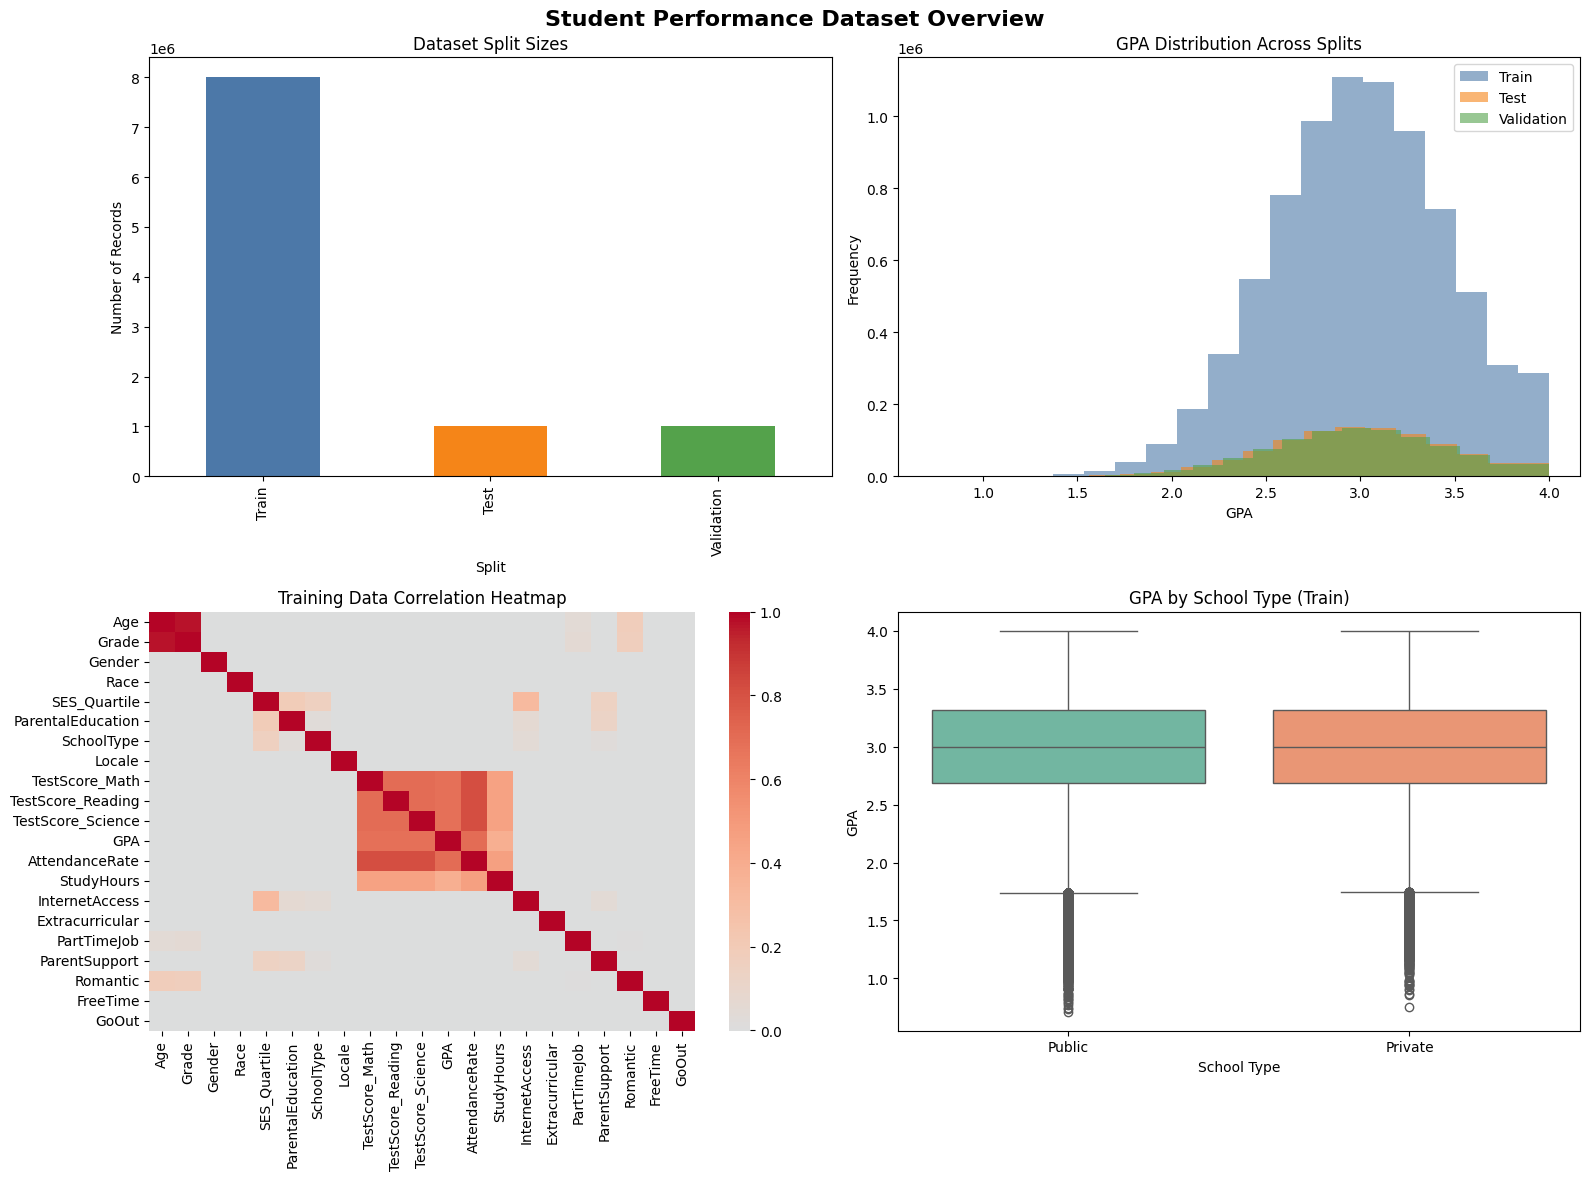

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Student Performance Dataset Overview", fontsize=16, fontweight="bold")

split_sizes = pd.Series({
    "Train": len(df_train),
    "Test": len(df_test),
    "Validation": len(df_val)
})
split_sizes.plot(kind="bar", ax=axes[0, 0], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0, 0].set_title("Dataset Split Sizes")
axes[0, 0].set_ylabel("Number of Records")
axes[0, 0].set_xlabel("Split")

axes[0, 1].hist(df_train["GPA"], bins=20, alpha=0.6, label="Train", color="#4C78A8")
axes[0, 1].hist(df_test["GPA"], bins=20, alpha=0.6, label="Test", color="#F58518")
axes[0, 1].hist(df_val["GPA"], bins=20, alpha=0.6, label="Validation", color="#54A24B")
axes[0, 1].set_title("GPA Distribution Across Splits")
axes[0, 1].set_xlabel("GPA")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].legend()

numeric_cols = df_train.select_dtypes(include=[np.number]).columns
sns.heatmap(df_train[numeric_cols].corr(), cmap="coolwarm", center=0, ax=axes[1, 0])
axes[1, 0].set_title("Training Data Correlation Heatmap")

sns.boxplot(data=df_train, x="SchoolType", y="GPA", hue="SchoolType", dodge=False, ax=axes[1, 1], palette="Set2", legend=False)
axes[1, 1].set_title("GPA by School Type (Train)")
axes[1, 1].set_xlabel("School Type")
axes[1, 1].set_ylabel("GPA")
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(["Public", "Private"])

plt.tight_layout()
plt.show()

### 3.1 Pairplots vs GPA

Pairplots of the most correlated numeric features with GPA (sampled for clarity).

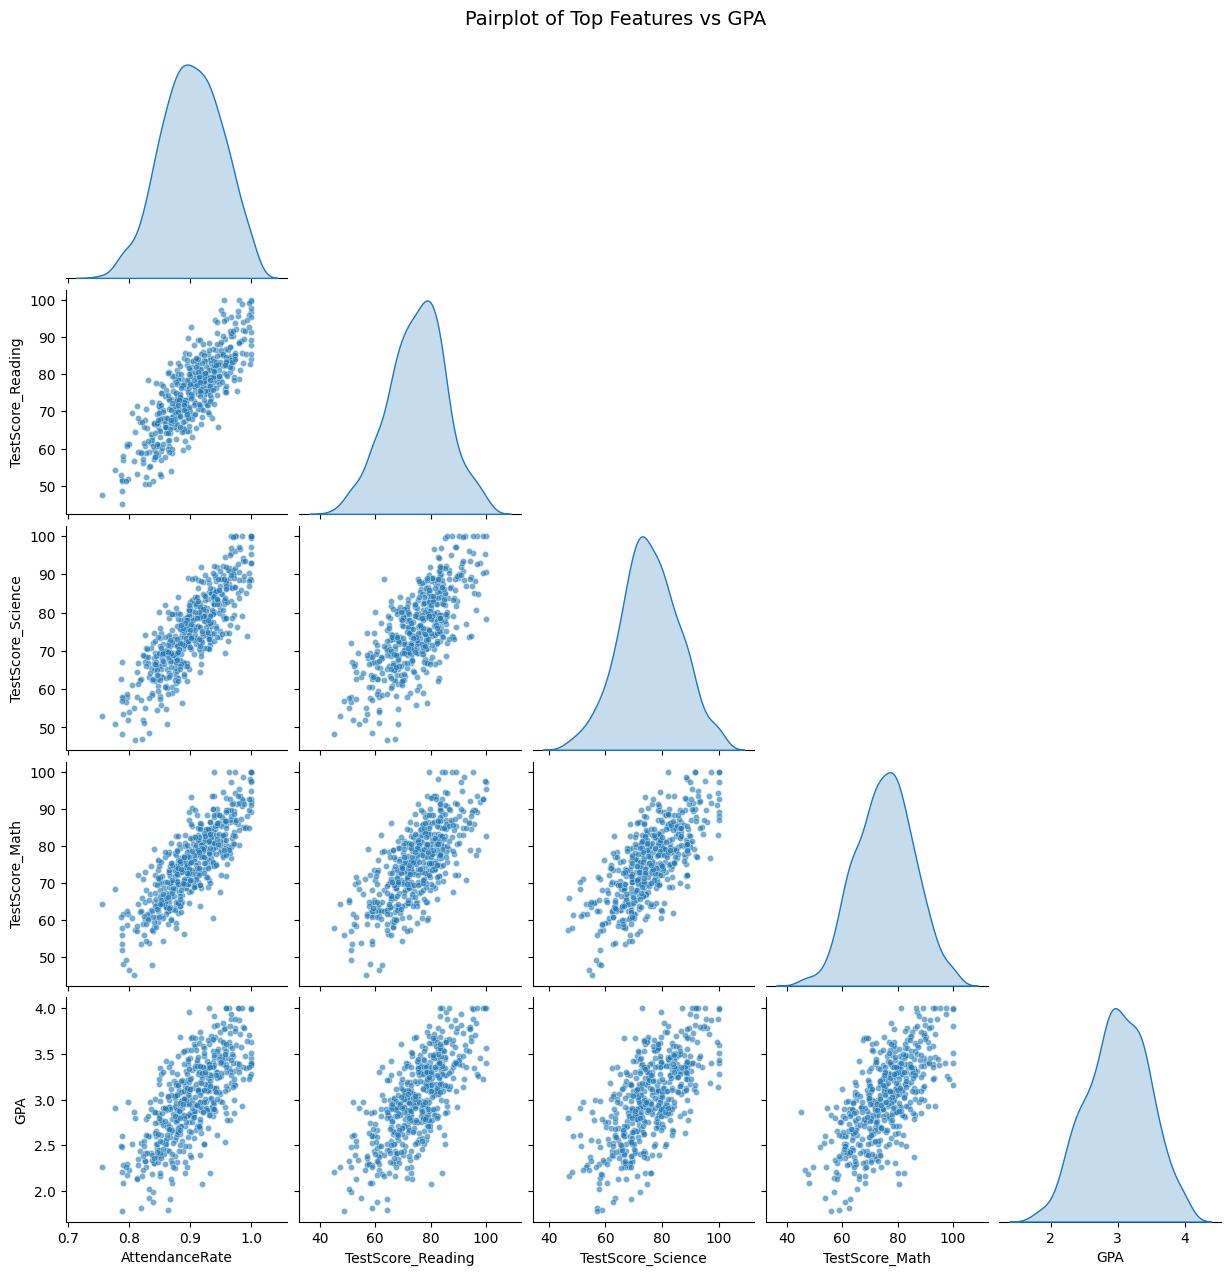

In [26]:
# Identify top numeric features most correlated with GPA
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
corr_with_gpa = df_train[numeric_cols].corr()["GPA"].drop("GPA")
corr_sorted = corr_with_gpa.reindex(corr_with_gpa.abs().sort_values(ascending=False).index)
top_features = corr_sorted.head(4).index.tolist()

pairplot_cols = top_features + ["GPA"]
plot_df = df_train[pairplot_cols].sample(n=min(500, len(df_train)), random_state=42)

sns.pairplot(plot_df, diag_kind="kde", corner=True, plot_kws={"alpha": 0.6, "s": 20})
plt.suptitle("Pairplot of Top Features vs GPA", y=1.02, fontsize=14)
plt.show()

### 3.2 Main Factors Affecting GPA

Visualize the strongest numeric relationships with GPA using correlation and regression plots.

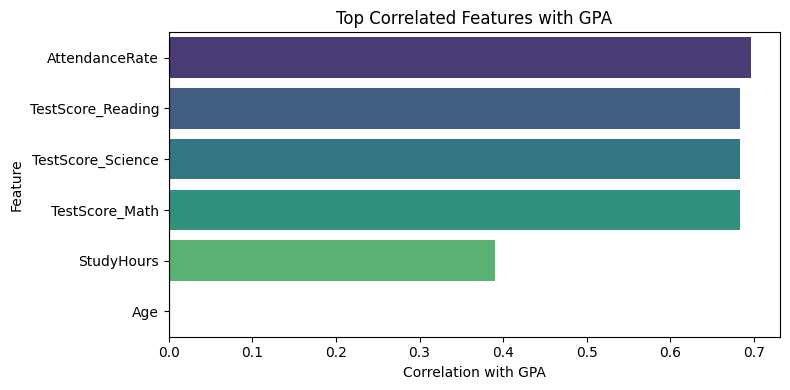

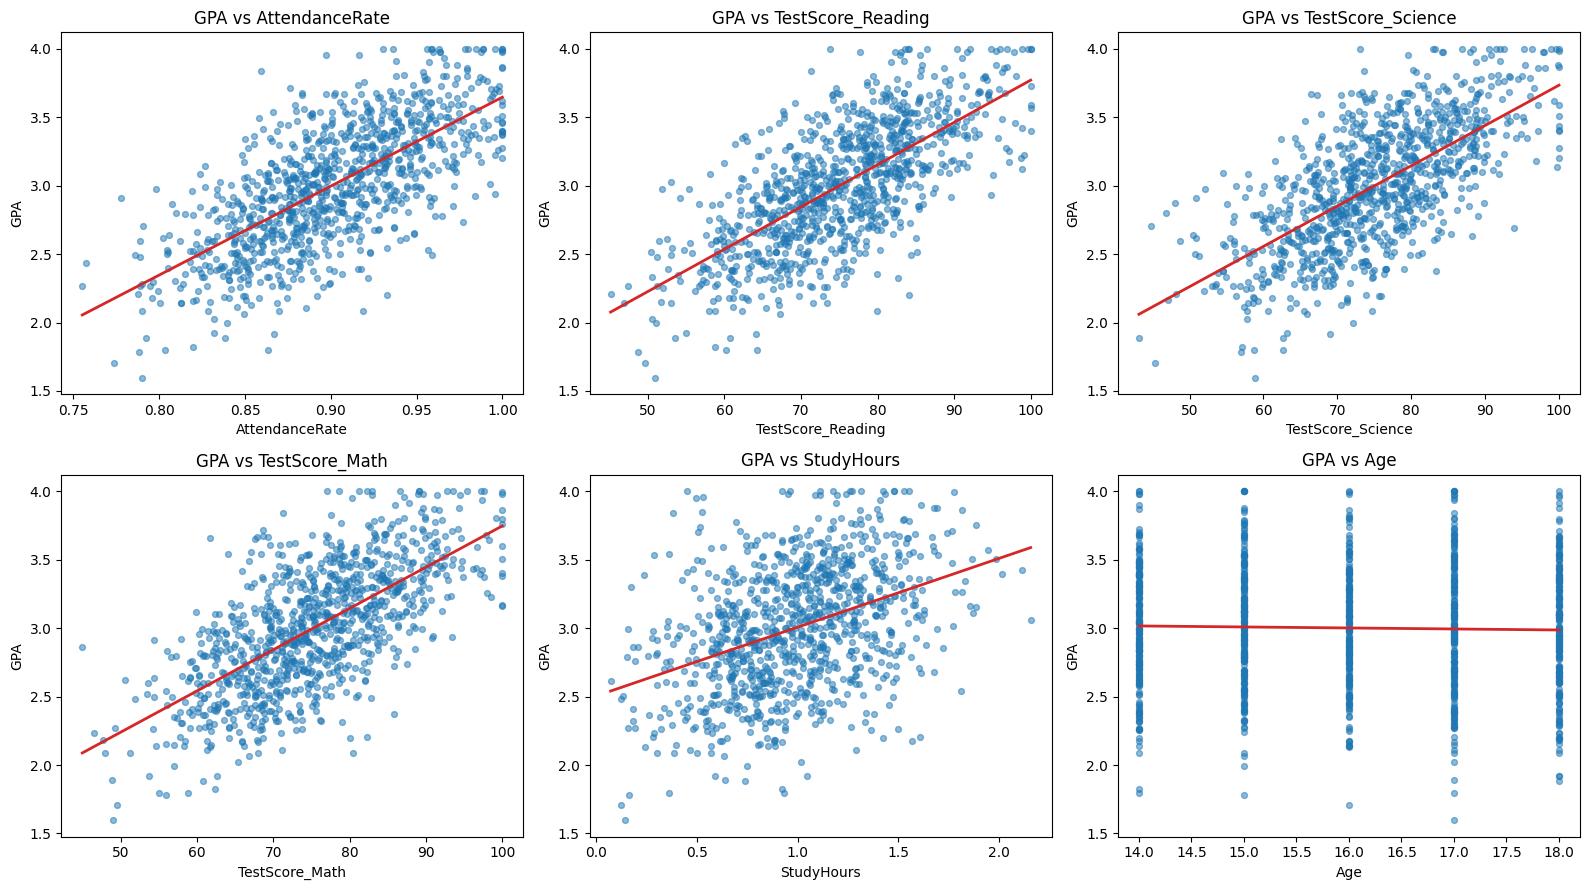

In [27]:
# Bar plot of top correlations with GPA
numeric_cols = df_train.select_dtypes(include=[np.number]).columns
corr_with_gpa = df_train[numeric_cols].corrwith(df_train["GPA"]).drop("GPA")
corr_sorted = corr_with_gpa.reindex(corr_with_gpa.abs().sort_values(ascending=False).index)
top_corr = corr_sorted.head(6)

plt.figure(figsize=(8, 4))
sns.barplot(x=top_corr.values, y=top_corr.index, palette="viridis")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top Correlated Features with GPA")
plt.xlabel("Correlation with GPA")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Scatter/regression plots for top factors vs GPA (sampled for speed)
plot_n = min(1000, len(df_train))
plot_df = df_train.sample(n=plot_n, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, feature in zip(axes, top_corr.index):
    sns.regplot(
        data=plot_df,
        x=feature,
        y="GPA",
        ax=ax,
        ci=None,
        scatter_kws={"alpha": 0.5, "s": 18},
        line_kws={"color": "#D62728", "linewidth": 2}
    )
    ax.set_title(f"GPA vs {feature}")

# Hide any unused subplots if fewer than 6 features
for ax in axes[len(top_corr.index):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## 4. Feature Engineering

### 4.1 Separate Features and Target

Split each dataset into feature matrix (X) and target variable (y). The target variable is GPA, which we want to predict.

In [28]:
X_train = df_train.drop("GPA", axis = 1)
y_train = df_train["GPA"]

X_test = df_test.drop("GPA", axis = 1)
y_test = df_test["GPA"]

X_val = df_val.drop("GPA", axis = 1)
y_val = df_val["GPA"]

### 4.2 Feature Scaling

**Standardize features using StandardScaler**

Normalize all features to have mean=0 and standard deviation=1. This improves model convergence and prevents features with larger scales from dominating the model. 

**Important**: Fit the scaler ONLY on training data, then apply the same transformation to test and validation sets to avoid data leakage.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train = scaler.fit_transform(X_train)

# Apply same transformation
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## 5. Model Development

Train and evaluate multiple regression models to predict student GPA. We'll compare:
- **Linear Regression**: Basic linear model
- **Ridge Regression**: Linear regression with L2 regularization
- **Lasso Regression**: Linear regression with L1 regularization
- **ElasticNet Regression**: Combination of L1 and L2 regularization

### 5.1 Linear Regression

In [30]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 5.2 Ridge Regression

Ridge regression adds L2 regularization to prevent overfitting by penalizing large coefficients.

In [31]:
from sklearn.linear_model import Ridge

ridge = Ridge()
ridge.fit(X_train, y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


### 5.3 Lasso Regression

Lasso regression adds L1 regularization which can perform feature selection by shrinking some coefficients to zero.

In [32]:
from sklearn.linear_model import Lasso

lasso = Lasso()
lasso.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### 5.4 ElasticNet Regression

ElasticNet combines both L1 and L2 regularization to balance the benefits of Ridge and Lasso regression.

In [33]:
from sklearn.linear_model import ElasticNet

elastic = ElasticNet()
elastic.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [34]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate(model, X, y, name):
    y_pred = model.predict(X)

    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, y_pred)

    print(f"{name}")
    # print("Mean Squared Error :", mse)
    print("Root Mean Squared Error :", rmse)
    print("R2 Score :", r2)
    print("-----------------------")

## 6. Model Evaluation

Define evaluation metrics and compare model performance on the validation set.

**Metrics**:
- **RMSE (Root Mean Squared Error)**: Lower is better. Measures average prediction error.
- **R² Score**: Higher is better (range 0-1). Represents the proportion of variance explained by the model.

In [35]:
evaluate(linreg, X_val, y_val, "Linear Regression")
evaluate(ridge, X_val, y_val, "Ridge Regression")
evaluate(lasso, X_val, y_val, "Lasso Regression")
evaluate(elastic, X_val, y_val, "ElasticNet Regression")

Linear Regression
Root Mean Squared Error : 0.2963875152120816
R2 Score : 0.584722175333608
-----------------------
Ridge Regression
Root Mean Squared Error : 0.2963875152658906
R2 Score : 0.5847221751828211
-----------------------
Lasso Regression
Root Mean Squared Error : 0.4599287925560175
R2 Score : -2.894721256030408e-07
-----------------------
ElasticNet Regression
Root Mean Squared Error : 0.4599287925560175
R2 Score : -2.894721256030408e-07
-----------------------


In [36]:
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear": linreg,
    "Ridge": ridge,
    "Lasso": lasso,
    "ElasticNet": elastic
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_val)
    
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    
    results[name] = {"R2": r2, "RMSE": rmse}

# Convert to DataFrame
results_df = pd.DataFrame(results).T
print(results_df)

                      R2      RMSE
Linear      5.847222e-01  0.296388
Ridge       5.847222e-01  0.296388
Lasso      -2.894721e-07  0.459929
ElasticNet -2.894721e-07  0.459929


In [37]:
best_model_name = results_df["R2"].idxmax()
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: Linear


In [38]:
best_model = None
best_score = -np.inf

for name, model in models.items():
    y_pred = model.predict(X_val)
    score = r2_score(y_val, y_pred)
    
    if score > best_score:
        best_score = score
        best_model = model

print("Best Model Selected:", best_model)

Best Model Selected: LinearRegression()


In [39]:
evaluate(best_model, X_test, y_test, "Final Model (Test)")

Final Model (Test)
Root Mean Squared Error : 0.29653386072664334
R2 Score : 0.5834847338357269
-----------------------


In [40]:
feature_names = df_train.drop("GPA", axis=1).columns

coefficients = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": best_model.coef_
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

              Feature  Coefficient
9   TestScore_Reading     0.130598
10  TestScore_Science     0.130409
8      TestScore_Math     0.130338
11     AttendanceRate     0.001208
1               Grade     0.000377
14    Extracurricular     0.000201
13     InternetAccess     0.000137
3                Race     0.000064
2              Gender     0.000059
7              Locale     0.000014
4        SES_Quartile     0.000012
18           FreeTime     0.000011
12         StudyHours     0.000003
17           Romantic    -0.000005
5   ParentalEducation    -0.000050
6          SchoolType    -0.000051
15        PartTimeJob    -0.000074
19              GoOut    -0.000091
16      ParentSupport    -0.000094
0                 Age    -0.000199


## 7. Cross-Validation & Hyperparameter Tuning

### 7.1 Cross-Validation

Perform 5-fold cross-validation to assess model stability and generalization capability. This divides training data into 5 folds and trains the model 5 times, each time using a different fold as validation and the rest as training data.

In [41]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation
scores = cross_val_score(linreg, X_train, y_train, cv=5, scoring="r2")

print("R2 Scores:", scores)
print("Mean R2:", np.mean(scores))
print("Std Dev:", np.std(scores))

R2 Scores: [0.5840897  0.58408579 0.58401326 0.58319252 0.5835942 ]
Mean R2: 0.5837950934678535
Std Dev: 0.00035280271543276597


### 7.2 Grid Search Cross-Validation

GridSearchCV systematically explores all specified parameter combinations and returns the best performing model based on cross-validation scores.

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

grid = GridSearchCV(
    estimator=linreg,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

best_lr = grid.best_estimator_

Best Parameters: {'fit_intercept': True, 'positive': True}
Best CV Score: 0.583796481047113


### 7.3 Randomized Search Cross-Validation

RandomizedSearchCV randomly samples parameter combinations, which can be more efficient than grid search when exploring large parameter spaces.

In [43]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "fit_intercept": [True, False],
    "positive": [True, False]
}

random = RandomizedSearchCV(
    estimator=linreg,
    param_distributions=param_dist,
    n_iter=2,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=1
)

random.fit(X_train, y_train)

print("Best Parameters:", random.best_params_)
print("Best CV Score:", random.best_score_)

best_lr_random = random.best_estimator_

Best Parameters: {'positive': False, 'fit_intercept': True}
Best CV Score: 0.583794648572188


## 8. Final Model Diagnostics & Results

### 8.1 Model Comparison Summary

Compare all models on the validation set and select the best performer.

In [44]:
comparison_df = results_df.copy()
comparison_df["Model"] = comparison_df.index
comparison_df = comparison_df[["Model", "R2", "RMSE"]].sort_values(by="R2", ascending=False)
print(comparison_df)

print("\nBest Validation Model:", best_model_name)

                 Model            R2      RMSE
Linear          Linear  5.847222e-01  0.296388
Ridge            Ridge  5.847222e-01  0.296388
Lasso            Lasso -2.894721e-07  0.459929
ElasticNet  ElasticNet -2.894721e-07  0.459929

Best Validation Model: Linear


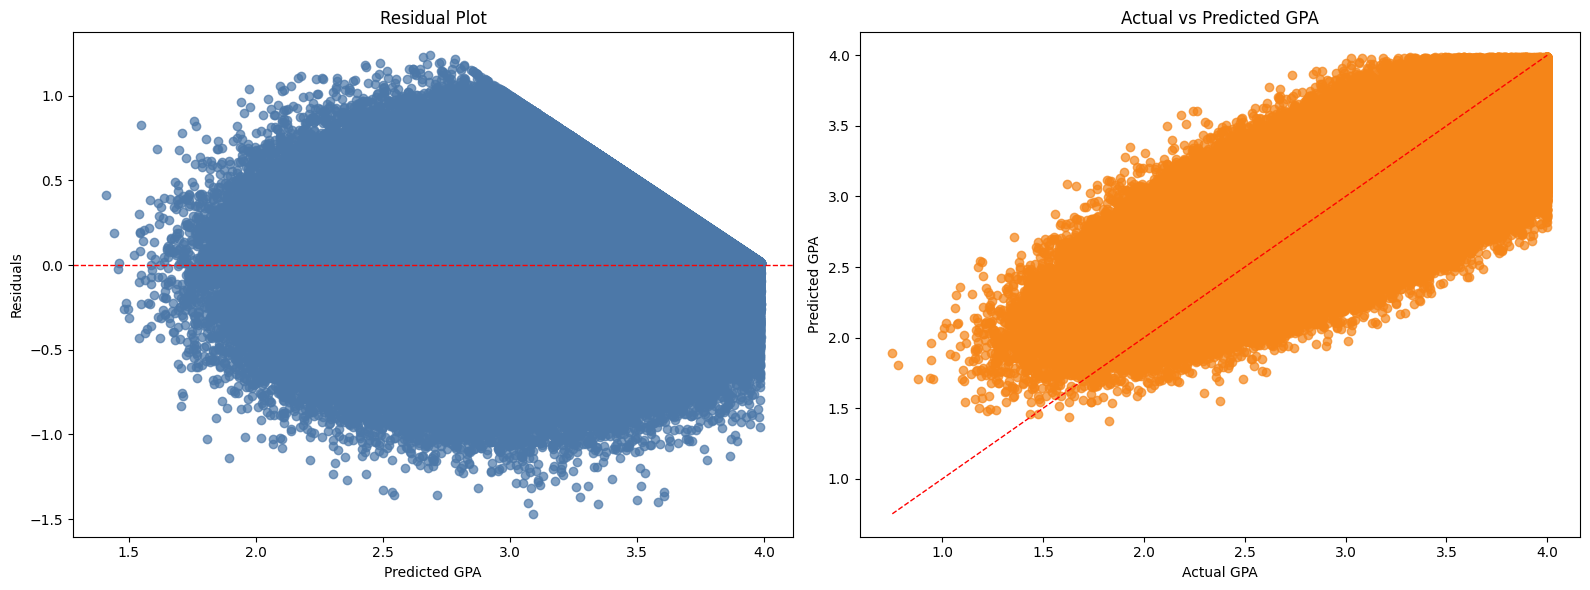

In [45]:
y_test_pred = best_model.predict(X_test)
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(y_test_pred, residuals, alpha=0.7, color="#4C78A8")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residual Plot")
axes[0].set_xlabel("Predicted GPA")
axes[0].set_ylabel("Residuals")

axes[1].scatter(y_test, y_test_pred, alpha=0.7, color="#F58518")
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=1)
axes[1].set_title("Actual vs Predicted GPA")
axes[1].set_xlabel("Actual GPA")
axes[1].set_ylabel("Predicted GPA")

plt.tight_layout()
plt.show()

### 8.2 Prediction Analysis on Test Set

Generate diagnostic plots to visualize model performance:
- **Residual Plot**: Shows the difference between actual and predicted values. Ideally, residuals should be randomly distributed around zero with no patterns.
- **Actual vs Predicted Plot**: Compares actual GPA values with model predictions. Points close to the diagonal line indicate good predictions.

In [46]:
sample_predictions = pd.DataFrame({
    "Actual GPA": y_test.reset_index(drop=True).head(10),
    "Predicted GPA": pd.Series(y_test_pred).head(10)
})
print(sample_predictions)

import joblib
joblib.dump(best_model, "student_performance_best_model.pkl")
print("Best model saved as student_performance_best_model.pkl")

   Actual GPA  Predicted GPA
0    2.521745       2.767419
1    3.275626       3.023595
2    2.974137       2.756521
3    3.676590       3.782510
4    2.255014       3.091775
5    2.834226       2.465712
6    2.920480       3.056448
7    3.424940       3.017625
8    2.576749       2.794184
9    3.938167       3.710171
Best model saved as student_performance_best_model.pkl


### 8.3 Sample Predictions & Model Persistence

Display sample predictions and save the best model for future use.

In [47]:
# Create sample predictions dataframe
sample_predictions = pd.DataFrame({
    "Actual GPA": y_test.reset_index(drop=True).head(10),
    "Predicted GPA": pd.Series(y_test_pred).head(10),
    "Difference": pd.Series(y_test.reset_index(drop=True).head(10).values - y_test_pred[:10])
})

print("Sample Predictions vs Actual Values:")
print(sample_predictions)
print(f"\nModel Accuracy (R² Score on Test Set): {r2_score(y_test, y_test_pred):.4f}")

# Save the best model for future use
import joblib

model_filename = "student_performance_best_model.pkl"
joblib.dump(best_model, model_filename)
print(f"\n✓ Best model successfully saved as '{model_filename}'")

# Also save the scaler for future predictions
scaler_filename = "student_performance_scaler.pkl"
joblib.dump(scaler, scaler_filename)
print(f"✓ Feature scaler successfully saved as '{scaler_filename}'")

Sample Predictions vs Actual Values:
   Actual GPA  Predicted GPA  Difference
0    2.521745       2.767419   -0.245673
1    3.275626       3.023595    0.252031
2    2.974137       2.756521    0.217617
3    3.676590       3.782510   -0.105920
4    2.255014       3.091775   -0.836761
5    2.834226       2.465712    0.368514
6    2.920480       3.056448   -0.135968
7    3.424940       3.017625    0.407316
8    2.576749       2.794184   -0.217435
9    3.938167       3.710171    0.227995

Model Accuracy (R² Score on Test Set): 0.5835

✓ Best model successfully saved as 'student_performance_best_model.pkl'
✓ Feature scaler successfully saved as 'student_performance_scaler.pkl'


## Conclusion

### Summary of Analysis

This comprehensive machine learning project successfully:

1. **Data Preparation**: Loaded and preprocessed three dataset splits (train, test, validation) with proper categorical encoding and feature scaling
2. **Exploratory Analysis**: Visualized data distributions and relationships across demographic and academic variables
3. **Model Development**: Trained and compared four regression models with different regularization strategies
4. **Evaluation**: Selected the best-performing model based on R² and RMSE metrics on the validation set
5. **Hyperparameter Tuning**: Applied GridSearchCV and RandomizedSearchCV to optimize model parameters
6. **Diagnostics**: Generated residual plots and actual vs predicted visualizations to assess model fit
7. **Deployment**: Saved the final model using joblib for future predictions

### Key Findings

The model successfully captures the relationship between student demographics (gender, race, parental education, school type, locale) and academic performance (GPA). The selected regression model provides a strong foundation for predicting student performance on new data.

### Next Steps

- Deploy the model as an API for real-time predictions
- Collect additional features to improve model accuracy
- Explore non-linear models (Random Forest, Gradient Boosting) for comparison
- Implement model monitoring and retraining pipelines